# Code-Capacity Spatial Marginal Animations (HzGrid)

This companion notebook keeps the same half-stabilizer trace setup, but defaults to an `Hz` incidence grid when the Tanner graph gets too dense. The grid orders flipped bits and support bits to the front, and marks active syndrome rows explicitly so the selected case is still easy to read.

Leave `visualization_mode = "auto"` to use graph rendering for surface-style codes and `HzGrid` for larger-degree codes, or force `"hz_grid"` / `"graph"` manually when needed.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, Video, display
from matplotlib.animation import FuncAnimation, FFMpegWriter, PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, TwoSlopeNorm


In [6]:
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=140, suppress=True)


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import relay_bp
from relay_bp.analysis import (
    build_half_stabilizer_case_from_seed,
    default_export_code_paths,
    evaluate_decode_result,
    load_code_capacity_problem,
    with_uniform_error_rate,
)


def notebook_code_paths(repo_root: Path) -> dict[str, Path]:
    paths = default_export_code_paths(repo_root)
    extra_candidates = {
        "surface13": [
            repo_root / "examples" / "notebook_data" / "stim_decoder_npz_exports" / "surface13_raw_HxHzLxLz.npz",
            Path(r"C:\Users\User\Documents\Code from BPGD\surface13_HxHzLxLz.npz"),
        ],
        "surface5": [
            repo_root / "examples" / "notebook_data" / "stim_decoder_npz_exports" / "surface5_from_stim_Z_basis_fault_projection.npz",
            Path(r"C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz"),
        ],
        "hgp_625": [
            Path(r"C:\Users\User\Documents\projects-git\giulio\hgp_code_625_25_6_peg.npz"),
        ],
        "hgp_225": [
            Path(r"C:\Users\User\Documents\cluster_decoder\cluster_decoder\codes\hgp_code_225.npz"),
        ],
        "B1": [
            Path(r"C:\Users\User\Documents\projects-git\bpgd_low_llr_and_hybrid\B1_HxHzLxLz.npz"),
        ],
    }
    for key, candidates in extra_candidates.items():
        for candidate in candidates:
            if candidate.exists():
                paths[key] = candidate
                break
    return paths


CODE_PATHS = notebook_code_paths(REPO_ROOT)
selected_code = "surface5"
if selected_code not in CODE_PATHS:
    selected_code = sorted(CODE_PATHS)[0]
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.01
max_iter = 40
alpha = 1.0
same_memory_coefficient = 0.15
random_positive_range = (0.0, 2.0)
random_signed_range = (-0.1, 1.9)
memory_application_scope = "all_bits"  # options: "stabilizer_support", "all_bits"
random_coefficient_seed_offsets = [0, 1, 2]

selected_decoder_kind = "bp"
selected_core_seed = 0
batch_core_seeds = [1, 2, 3]

animation_output_dir = REPO_ROOT / ".tmp" / "marginal_spatial_animations" / "hz_grid"
animation_fps = 2
animation_formats = ("gif",)
display_inline_animation = True

visualization_mode = "auto"  # options: "graph", "hz_grid", "auto"
hz_grid_order = "support_first"  # options: "natural", "degree", "support_first"
hz_grid_show_column_bias_background = False
hz_grid_max_dense_cells = 2_500_000

color_scale_mode = "fixed"  # options: "fixed", "run"
fixed_posterior_bound = 6.0
surface_style_codes = {"surface5", "surface13"}

DECODER_SPECS = {
    "bp": {
        "label": "Vanilla BP",
        "coeff_seed_offsets": [0],
    },
    "mem_same": {
        "label": "Mem-BP / same coefficient",
        "coeff_seed_offsets": [0],
    },
    "mem_positive_random": {
        "label": "Mem-BP / random positive coefficients",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
    "mem_signed_random": {
        "label": "Mem-BP / random signed coefficients",
        "coeff_seed_offsets": random_coefficient_seed_offsets,
    },
}


def resolve_visualization_mode(selected_code: str, requested_mode: str) -> str:
    if requested_mode == "auto":
        return "graph" if selected_code in surface_style_codes else "hz_grid"
    if requested_mode not in {"graph", "hz_grid"}:
        raise ValueError(f"Unsupported visualization_mode: {requested_mode}")
    return requested_mode


In [7]:
def load_code_problem(path: Path):
    base_problem = load_code_capacity_problem(path, default_prior_error_rate=prior_error_rate)
    return with_uniform_error_rate(base_problem, prior_error_rate)


def code_summary_table(problem) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "code": selected_code,
                "npz_path": str(problem.path),
                "Hx_shape": tuple(int(x) for x in problem.hx.shape),
                "Hz_shape": tuple(int(x) for x in problem.hz.shape),
                "Lz_shape": tuple(int(x) for x in problem.lz.shape),
                "prior_error_rate": float(prior_error_rate),
                "max_iter": int(max_iter),
                "same_memory_coefficient": float(same_memory_coefficient),
                "random_positive_range": tuple(float(x) for x in random_positive_range),
                "random_signed_range": tuple(float(x) for x in random_signed_range),
                "memory_application_scope": memory_application_scope,
                "visualization_mode": resolve_visualization_mode(selected_code, visualization_mode),
                "available_codes": ", ".join(sorted(CODE_PATHS)),
            }
        ]
    )


def get_memory_target_indices(n_bits: int, support_bits: tuple[int, ...]) -> np.ndarray:
    if memory_application_scope == "stabilizer_support":
        return np.asarray(support_bits, dtype=int)
    if memory_application_scope == "all_bits":
        return np.arange(n_bits, dtype=int)
    raise ValueError(f"Unsupported memory_application_scope: {memory_application_scope}")


def build_memory_strengths(decoder_kind: str, n_bits: int, support_bits: tuple[int, ...], coeff_seed: int) -> np.ndarray | None:
    if decoder_kind == "bp":
        return None

    target_indices = get_memory_target_indices(n_bits, support_bits)
    strengths = np.zeros(n_bits, dtype=np.float64)

    if decoder_kind == "mem_same":
        strengths[target_indices] = same_memory_coefficient
        return strengths

    rng = np.random.default_rng(int(coeff_seed))
    if decoder_kind == "mem_positive_random":
        strengths[target_indices] = rng.uniform(random_positive_range[0], random_positive_range[1], size=target_indices.size)
        return strengths

    if decoder_kind == "mem_signed_random":
        strengths[target_indices] = rng.uniform(random_signed_range[0], random_signed_range[1], size=target_indices.size)
        return strengths

    raise ValueError(f"Unsupported decoder kind: {decoder_kind}")


def make_tracer(problem, decoder_kind: str):
    gamma0 = None if decoder_kind == "bp" else 0.0
    return relay_bp.MinSumBPDecoderTraceF64(
        problem.hz,
        error_priors=np.asarray(problem.error_priors, dtype=np.float64),
        max_iter=int(max_iter),
        alpha=float(alpha),
        gamma0=gamma0,
    )


def run_single_trace(problem, case: dict[str, object], decoder_kind: str, coeff_seed_offset: int) -> dict[str, object]:
    coeff_seed = int(case["case_id"]) + int(coeff_seed_offset)
    tracer = make_tracer(problem, decoder_kind)
    tracer.reset()

    memory_strengths = build_memory_strengths(decoder_kind, problem.n_bits, case["support_bits"], coeff_seed)
    if memory_strengths is not None:
        tracer.set_memory_strengths(memory_strengths)

    syndrome = np.asarray(case["syndrome"], dtype=np.uint8)
    snapshots = [tracer.snapshot(syndrome)]
    while tracer.current_iteration < snapshots[-1].max_iter and not snapshots[-1].success:
        snapshots.append(tracer.run_iteration(syndrome))

    final_result = snapshots[-1]
    evaluation = evaluate_decode_result(result=final_result, error=case["error"], lz=problem.lz)
    posterior_trace = np.vstack([np.asarray(snapshot.posterior_ratios, dtype=np.float64) for snapshot in snapshots])
    return {
        "decoder_kind": decoder_kind,
        "coeff_seed": coeff_seed,
        "coeff_seed_offset": int(coeff_seed_offset),
        "memory_strengths": memory_strengths,
        "iterations": np.asarray([int(snapshot.iterations) for snapshot in snapshots], dtype=int),
        "posterior_trace": posterior_trace,
        "final_decoding": np.asarray(final_result.decoding, dtype=np.uint8),
        "final_decoded_detectors": np.asarray(final_result.decoded_detectors, dtype=np.uint8),
        "success": bool(final_result.success),
        "logical_success": bool(evaluation.logical_success),
        "exact_recovery": bool(evaluation.exact_recovery),
        "logical_weight": int(evaluation.logical_weight),
        "final_iterations": int(final_result.iterations),
    }


def run_decoder_experiment(core_seed: int, decoder_kind: str, problem) -> dict[str, object]:
    case = build_half_stabilizer_case_from_seed(problem, int(core_seed))
    runs = [
        run_single_trace(problem, case, decoder_kind, coeff_seed_offset)
        for coeff_seed_offset in DECODER_SPECS[decoder_kind]["coeff_seed_offsets"]
    ]
    return {
        "problem": problem,
        "case": case,
        "decoder_kind": decoder_kind,
        "decoder_label": DECODER_SPECS[decoder_kind]["label"],
        "runs": runs,
    }


def experiment_overview_table(experiment: dict[str, object]) -> pd.DataFrame:
    case = experiment["case"]
    syndrome_checks = np.flatnonzero(np.asarray(case["syndrome"], dtype=np.uint8)).astype(int).tolist()
    return pd.DataFrame(
        [
            {
                "decoder": experiment["decoder_label"],
                "core_seed": int(case["case_id"]),
                "hx_row": int(case["row_idx"]),
                "row_weight": int(case["row_weight"]),
                "support_bits": list(case["support_bits"]),
                "flipped_bits": list(case["flipped_bits"]),
                "syndrome_weight": int(case["syndrome_weight"]),
                "active_checks": syndrome_checks,
            }
        ]
    )


def run_summary_table(experiment: dict[str, object]) -> pd.DataFrame:
    case = experiment["case"]
    support_bit_set = set(int(bit) for bit in case["support_bits"])
    rows = []
    for run in experiment["runs"]:
        final_estimated_error_bits = np.flatnonzero(run["final_decoding"]).astype(int).tolist()
        estimated_bits_in_support = [bit for bit in final_estimated_error_bits if bit in support_bit_set]
        estimated_bits_outside_support = [bit for bit in final_estimated_error_bits if bit not in support_bit_set]
        rows.append(
            {
                "decoder": experiment["decoder_label"],
                "core_seed": int(case["case_id"]),
                "coeff_seed": int(run["coeff_seed"]),
                "coeff_seed_offset": int(run["coeff_seed_offset"]),
                "success": bool(run["success"]),
                "logical_success": bool(run["logical_success"]),
                "exact_recovery": bool(run["exact_recovery"]),
                "logical_weight": int(run["logical_weight"]),
                "iterations": int(run["final_iterations"]),
                "n_support_bits": len(case["support_bits"]),
                "n_flipped_bits": len(case["flipped_bits"]),
                "n_estimated_bits": len(final_estimated_error_bits),
                "estimated_bits_in_support": estimated_bits_in_support,
                "estimated_bits_outside_support": estimated_bits_outside_support,
            }
        )
    return pd.DataFrame(rows)


def top_posterior_bits_table(run: dict[str, object], case: dict[str, object], iteration: int = -1, top_k: int = 12) -> pd.DataFrame:
    posterior_vector = np.asarray(run["posterior_trace"][iteration], dtype=np.float64)
    support_bit_set = set(int(bit) for bit in case["support_bits"])
    flipped_bit_set = set(int(bit) for bit in case["flipped_bits"])
    ranked = np.argsort(-np.abs(posterior_vector))[: int(top_k)]
    rows = []
    for bit in ranked:
        rows.append(
            {
                "coeff_seed_offset": int(run["coeff_seed_offset"]),
                "bit": int(bit),
                "posterior_ratio": float(posterior_vector[int(bit)]),
                "abs_posterior_ratio": float(abs(posterior_vector[int(bit)])),
                "in_support": bool(int(bit) in support_bit_set),
                "flipped": bool(int(bit) in flipped_bit_set),
            }
        )
    return pd.DataFrame(rows)


_LAYOUT_CACHE: dict[str, tuple[nx.Graph, dict[str, np.ndarray]]] = {}


def build_tanner_graph_layout(problem, cache_key: str) -> tuple[nx.Graph, dict[str, np.ndarray]]:
    if cache_key in _LAYOUT_CACHE:
        return _LAYOUT_CACHE[cache_key]

    graph = nx.Graph()
    for check_idx in range(problem.hz.shape[0]):
        graph.add_node(f"c{check_idx}", kind="check", index=int(check_idx))
    hz = problem.hz.tocsc()
    for bit_idx in range(problem.n_bits):
        graph.add_node(f"v{bit_idx}", kind="variable", index=int(bit_idx))
        start = int(hz.indptr[bit_idx])
        end = int(hz.indptr[bit_idx + 1])
        for edge_idx in range(start, end):
            check_idx = int(hz.indices[edge_idx])
            graph.add_edge(
                f"c{check_idx}",
                f"v{bit_idx}",
                edge_idx=int(edge_idx),
                check_idx=int(check_idx),
                bit_idx=int(bit_idx),
            )

    try:
        raw_pos = nx.kamada_kawai_layout(graph)
    except Exception:
        raw_pos = nx.spring_layout(graph, seed=0, iterations=500)

    xs = np.asarray([float(raw_pos[node][0]) for node in graph.nodes()], dtype=np.float64)
    ys = np.asarray([float(raw_pos[node][1]) for node in graph.nodes()], dtype=np.float64)
    min_x, max_x = float(xs.min()), float(xs.max())
    min_y, max_y = float(ys.min()), float(ys.max())
    span_x = max(max_x - min_x, 1e-9)
    span_y = max(max_y - min_y, 1e-9)
    positions = {
        node: np.asarray(
            [
                (float(raw_pos[node][0]) - min_x) / span_x,
                1.0 - (float(raw_pos[node][1]) - min_y) / span_y,
            ],
            dtype=np.float64,
        )
        for node in graph.nodes()
    }
    _LAYOUT_CACHE[cache_key] = (graph, positions)
    return graph, positions


def posterior_ratio_norm(values: np.ndarray):
    if color_scale_mode == "fixed":
        bound = max(float(fixed_posterior_bound), 1e-6)
        return TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)

    finite = np.asarray(values[np.isfinite(values)], dtype=np.float64)
    if finite.size == 0:
        return Normalize(vmin=-1.0, vmax=1.0)
    vmin = float(finite.min())
    vmax = float(finite.max())
    if np.isclose(vmin, vmax):
        pad = 1.0 if np.isclose(vmin, 0.0) else max(abs(vmin) * 0.05, 1e-6)
        return Normalize(vmin=vmin - pad, vmax=vmax + pad)
    if vmin < 0.0 < vmax:
        bound = max(abs(vmin), abs(vmax))
        return TwoSlopeNorm(vmin=-bound, vcenter=0.0, vmax=bound)
    return Normalize(vmin=vmin, vmax=vmax)


def draw_spatial_iteration_frame(
    ax: plt.Axes,
    graph: nx.Graph,
    positions: dict[str, np.ndarray],
    posterior_vector: np.ndarray,
    case: dict[str, object],
    norm,
    cmap,
    title: str,
):
    neutral_edge = "#9ba1a6"
    neutral_check = "#8f959a"
    active_check = "#b91c1c"
    support_ring = "#111827"
    flipped_ring = "#d97706"

    edge_segments = []
    for left, right in graph.edges():
        edge_segments.append([positions[left], positions[right]])
    line_collection = LineCollection(edge_segments, colors=neutral_edge, linewidths=1.6, zorder=1)
    ax.add_collection(line_collection)

    check_nodes = [node for node, data in graph.nodes(data=True) if data["kind"] == "check"]
    variable_nodes = [node for node, data in graph.nodes(data=True) if data["kind"] == "variable"]
    active_check_set = set(int(idx) for idx in np.flatnonzero(np.asarray(case["syndrome"], dtype=np.uint8)).astype(int).tolist())
    inactive_check_nodes = [node for node in check_nodes if int(graph.nodes[node]["index"]) not in active_check_set]
    active_check_nodes = [node for node in check_nodes if int(graph.nodes[node]["index"]) in active_check_set]

    scale = max(1.0, np.sqrt(len(variable_nodes)) / 6.0)
    check_size = 34.0 / scale
    variable_size = 28.0 / scale

    if inactive_check_nodes:
        check_xy = np.asarray([positions[node] for node in inactive_check_nodes], dtype=np.float64)
        ax.scatter(
            check_xy[:, 0],
            check_xy[:, 1],
            s=check_size,
            c=neutral_check,
            edgecolors="#666b70",
            linewidths=0.5,
            zorder=3,
        )
    if active_check_nodes:
        check_xy = np.asarray([positions[node] for node in active_check_nodes], dtype=np.float64)
        ax.scatter(
            check_xy[:, 0],
            check_xy[:, 1],
            s=check_size * 1.15,
            c=active_check,
            edgecolors="#7f1d1d",
            linewidths=0.55,
            zorder=4,
        )

    variable_xy = np.asarray([positions[node] for node in variable_nodes], dtype=np.float64)
    variable_colors = [
        cmap(norm(float(posterior_vector[int(graph.nodes[node]["index"])])))
        for node in variable_nodes
    ]
    ax.scatter(
        variable_xy[:, 0],
        variable_xy[:, 1],
        s=variable_size,
        c=variable_colors,
        edgecolors="#666b70",
        linewidths=0.45,
        zorder=5,
    )

    support_nodes = [node for node in variable_nodes if int(graph.nodes[node]["index"]) in set(case["support_bits"])]
    flipped_nodes = [node for node in variable_nodes if int(graph.nodes[node]["index"]) in set(case["flipped_bits"])]
    if support_nodes:
        support_xy = np.asarray([positions[node] for node in support_nodes], dtype=np.float64)
        ax.scatter(
            support_xy[:, 0],
            support_xy[:, 1],
            s=variable_size * 1.8,
            facecolors="none",
            edgecolors=support_ring,
            linewidths=1.1,
            zorder=6,
        )
    if flipped_nodes:
        flipped_xy = np.asarray([positions[node] for node in flipped_nodes], dtype=np.float64)
        ax.scatter(
            flipped_xy[:, 0],
            flipped_xy[:, 1],
            s=variable_size * 2.35,
            facecolors="none",
            edgecolors=flipped_ring,
            linewidths=1.4,
            zorder=7,
        )

    ax.set_aspect("equal")
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.axis("off")
    ax.set_title(title, fontsize=10)


def hz_grid_orders(problem, case: dict[str, object], order: str = hz_grid_order) -> tuple[np.ndarray, np.ndarray]:
    matrix = problem.hz.tocsr()
    row_order = np.arange(matrix.shape[0], dtype=int)
    col_order = np.arange(matrix.shape[1], dtype=int)
    if order == "natural":
        return row_order, col_order
    row_degree = np.asarray(matrix.sum(axis=1)).reshape(-1)
    col_degree = np.asarray(matrix.sum(axis=0)).reshape(-1)
    if order == "degree":
        row_order = np.lexsort((row_order, row_degree))
        col_order = np.lexsort((col_order, col_degree))
        return row_order.astype(int), col_order.astype(int)
    if order == "support_first":
        syndrome_rows = np.flatnonzero(np.asarray(case["syndrome"], dtype=np.uint8)).astype(int)
        support_bits = np.asarray(case["support_bits"], dtype=int)
        flipped_bits = np.asarray(case["flipped_bits"], dtype=int)
        row_order = np.lexsort(
            (
                row_order,
                row_degree,
                ~np.isin(row_order, syndrome_rows),
            )
        )
        col_order = np.lexsort(
            (
                col_order,
                col_degree,
                ~np.isin(col_order, support_bits),
                ~np.isin(col_order, flipped_bits),
            )
        )
        return row_order.astype(int), col_order.astype(int)
    raise ValueError(f"Unsupported hz_grid_order: {order}")


def build_hz_grid_image(
    problem,
    posterior_vector: np.ndarray,
    norm,
    cmap,
    row_order: np.ndarray,
    col_order: np.ndarray,
    show_column_bias_background: bool = hz_grid_show_column_bias_background,
) -> np.ndarray:
    matrix = problem.hz.tocsr()[row_order, :][:, col_order]
    n_rows, n_cols = matrix.shape
    if n_rows * n_cols > hz_grid_max_dense_cells:
        raise ValueError(
            f"Hz grid would allocate {n_rows * n_cols:,} cells. "
            f"Increase hz_grid_max_dense_cells or choose a smaller code."
        )

    rgba = np.ones((n_rows, n_cols, 4), dtype=np.float64)
    if show_column_bias_background:
        column_colors = cmap(norm(np.asarray(posterior_vector[col_order], dtype=np.float64)))
        rgba[:, :, :] = column_colors[np.newaxis, :, :]
        rgba[:, :, 3] = 0.16
    else:
        rgba[:, :, :] = (1.0, 1.0, 1.0, 1.0)

    coo = matrix.tocoo()
    if coo.nnz:
        values = np.asarray(posterior_vector[col_order[coo.col]], dtype=np.float64)
        rgba[coo.row, coo.col, :] = cmap(norm(values))
        rgba[coo.row, coo.col, 3] = 1.0
    return rgba


def draw_hz_grid_iteration_frame(
    ax: plt.Axes,
    problem,
    case: dict[str, object],
    posterior_vector: np.ndarray,
    norm,
    cmap,
    row_order: np.ndarray,
    col_order: np.ndarray,
    title: str,
):
    image = build_hz_grid_image(
        problem=problem,
        posterior_vector=posterior_vector,
        norm=norm,
        cmap=cmap,
        row_order=row_order,
        col_order=col_order,
    )
    ax.imshow(image, interpolation="nearest", aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("bits / columns")
    ax.set_ylabel("Z checks / rows")

    n_rows, n_cols = image.shape[:2]
    if n_rows <= 80 and n_cols <= 160:
        ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
        ax.grid(which="minor", color="#c9cdd1", linestyle="-", linewidth=0.25)
        ax.tick_params(which="minor", bottom=False, left=False)
    else:
        ax.grid(False)

    ordered_support = np.flatnonzero(np.isin(col_order, np.asarray(case["support_bits"], dtype=int)))
    ordered_flipped = np.flatnonzero(np.isin(col_order, np.asarray(case["flipped_bits"], dtype=int)))
    ordered_syndrome = np.flatnonzero(
        np.isin(row_order, np.flatnonzero(np.asarray(case["syndrome"], dtype=np.uint8)).astype(int))
    )

    if ordered_support.size:
        ax.scatter(
            ordered_support,
            np.full(ordered_support.shape[0], -1.0),
            marker="s",
            s=18,
            c="#111827",
            clip_on=False,
            zorder=5,
        )
    if ordered_flipped.size:
        ax.scatter(
            ordered_flipped,
            np.full(ordered_flipped.shape[0], -2.0),
            marker="s",
            s=24,
            c="#d97706",
            clip_on=False,
            zorder=6,
        )
    if ordered_syndrome.size:
        ax.scatter(
            np.full(ordered_syndrome.shape[0], -1.0),
            ordered_syndrome,
            marker="s",
            s=22,
            c="#b91c1c",
            clip_on=False,
            zorder=6,
        )

    ax.set_xlim(-1.8, n_cols - 0.5)
    ax.set_ylim(n_rows - 0.5, -2.8)


def animation_title(experiment: dict[str, object], run: dict[str, object], frame_idx: int, mode: str) -> str:
    case = experiment["case"]
    prefix = "Hz grid" if mode == "hz_grid" else "Graph"
    return (
        f"{prefix} | {experiment['decoder_label']} | {selected_code} | core {case['case_id']} | "
        f"coeff +{run['coeff_seed_offset']}\n"
        f"iter {int(run['iterations'][frame_idx])} / {int(run['iterations'][-1])} | "
        f"success={run['success']} | logical={run['logical_success']} | "
        f"Hx row={case['row_idx']} | flipped={list(case['flipped_bits'])}"
    )


def save_animation(animation, stem: str, output_dir: Path | None = None, formats: tuple[str, ...] = animation_formats, fps: int = animation_fps) -> list[Path]:
    output_dir = animation_output_dir if output_dir is None else Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    saved_paths: list[Path] = []
    for fmt in formats:
        fmt = fmt.lower().strip().lstrip(".")
        path = output_dir / f"{stem}.{fmt}"
        if fmt == "gif":
            animation.save(path, writer=PillowWriter(fps=fps))
            saved_paths.append(path)
        elif fmt == "mp4":
            try:
                animation.save(path, writer=FFMpegWriter(fps=fps, bitrate=1800))
                saved_paths.append(path)
            except Exception as exc:
                print(f"Skipping MP4 for {stem}: {exc}")
        else:
            raise ValueError(f"Unsupported animation format: {fmt}")
    return saved_paths


def make_iteration_animation(
    experiment: dict[str, object],
    run_index: int = 0,
    *,
    requested_mode: str | None = None,
    output_dir: Path | None = None,
    formats: tuple[str, ...] = animation_formats,
    fps: int = animation_fps,
) -> list[Path]:
    mode = resolve_visualization_mode(selected_code, visualization_mode if requested_mode is None else requested_mode)
    problem = experiment["problem"]
    case = experiment["case"]
    run = experiment["runs"][run_index]
    norm = posterior_ratio_norm(run["posterior_trace"])
    cmap = plt.cm.RdBu_r

    if mode == "graph":
        graph, positions = build_tanner_graph_layout(problem, f"{selected_code}:{problem.n_bits}")
        fig, ax = plt.subplots(figsize=(7.6, 5.6), constrained_layout=True)
        sm = ScalarMappable(norm=norm, cmap=cmap)
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label("posterior ratio")

        def update(frame_idx: int):
            ax.clear()
            draw_spatial_iteration_frame(
                ax=ax,
                graph=graph,
                positions=positions,
                posterior_vector=run["posterior_trace"][frame_idx],
                case=case,
                norm=norm,
                cmap=cmap,
                title=animation_title(experiment, run, frame_idx, mode),
            )
            return []

        stem_suffix = "graph"
    elif mode == "hz_grid":
        row_order, col_order = hz_grid_orders(problem, case, order=hz_grid_order)
        fig_width = min(14.0, max(7.0, problem.hz.shape[1] / 28.0))
        fig_height = min(10.0, max(5.0, problem.hz.shape[0] / 28.0))
        fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
        sm = ScalarMappable(norm=norm, cmap=cmap)
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label("posterior ratio")

        def update(frame_idx: int):
            ax.clear()
            draw_hz_grid_iteration_frame(
                ax=ax,
                problem=problem,
                case=case,
                posterior_vector=run["posterior_trace"][frame_idx],
                norm=norm,
                cmap=cmap,
                row_order=row_order,
                col_order=col_order,
                title=animation_title(experiment, run, frame_idx, mode),
            )
            return []

        stem_suffix = "hzgrid"
    else:
        raise ValueError(f"Unsupported visualization mode: {mode}")

    animation = FuncAnimation(
        fig,
        update,
        frames=range(run["posterior_trace"].shape[0]),
        interval=int(1000 / max(fps, 1)),
        blit=False,
        repeat=True,
    )
    stem = f"{selected_code}_{experiment['decoder_kind']}_core{case['case_id']}_coeffplus{run['coeff_seed_offset']}_{stem_suffix}"
    saved_paths = save_animation(animation, stem, output_dir=output_dir, formats=formats, fps=fps)
    plt.close(fig)
    return saved_paths


def make_core_seed_experiment_animations(experiment: dict[str, object], *, requested_mode: str | None = None) -> pd.DataFrame:
    rows = []
    mode = resolve_visualization_mode(selected_code, visualization_mode if requested_mode is None else requested_mode)
    for run_index, run in enumerate(experiment["runs"]):
        paths = make_iteration_animation(experiment, run_index=run_index, requested_mode=mode)
        for path in paths:
            rows.append(
                {
                    "visualization_mode": mode,
                    "decoder": experiment["decoder_label"],
                    "core_seed": int(experiment["case"]["case_id"]),
                    "coeff_seed_offset": int(run["coeff_seed_offset"]),
                    "format": path.suffix.lstrip("."),
                    "path": str(path),
                }
            )
    return pd.DataFrame(rows)


def display_saved_animations(paths: list[Path]) -> None:
    if not display_inline_animation:
        return
    for path in paths:
        suffix = path.suffix.lower()
        if suffix == ".gif":
            display(Image(filename=str(path)))
        elif suffix == ".mp4":
            display(Video(str(path), embed=True))


def render_experiment_preview(experiment: dict[str, object], *, requested_mode: str | None = None) -> pd.DataFrame:
    display(experiment_overview_table(experiment))
    display(run_summary_table(experiment))
    top_tables = [top_posterior_bits_table(run, experiment["case"]) for run in experiment["runs"]]
    if top_tables:
        display(pd.concat(top_tables, ignore_index=True))
    artifacts = make_core_seed_experiment_animations(experiment, requested_mode=requested_mode)
    display(artifacts)
    if not artifacts.empty:
        display_saved_animations([Path(path) for path in artifacts["path"].tolist()])
    return artifacts


def export_seed_batch(problem, decoder_kind: str, core_seeds: list[int], *, requested_mode: str | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    experiments = [run_decoder_experiment(core_seed, decoder_kind, problem) for core_seed in core_seeds]
    run_tables = pd.concat([run_summary_table(experiment) for experiment in experiments], ignore_index=True)
    animation_tables = []
    for experiment in experiments:
        animation_tables.append(make_core_seed_experiment_animations(experiment, requested_mode=requested_mode))
    animations = pd.concat(animation_tables, ignore_index=True) if animation_tables else pd.DataFrame()
    return run_tables, animations


In [8]:
_smoke_key = "surface13" if "surface13" in CODE_PATHS else sorted(CODE_PATHS)[0]
_smoke_problem = load_code_problem(CODE_PATHS[_smoke_key])
_smoke_experiment = run_decoder_experiment(0, "bp", _smoke_problem)
_smoke_run = _smoke_experiment["runs"][0]
assert _smoke_run["posterior_trace"].shape[1] == _smoke_problem.n_bits
assert _smoke_run["iterations"][0] == 0

_graph, _positions = build_tanner_graph_layout(_smoke_problem, f"smoke:{_smoke_key}")
_fig, _ax = plt.subplots(figsize=(4.0, 3.0))
draw_spatial_iteration_frame(
    ax=_ax,
    graph=_graph,
    positions=_positions,
    posterior_vector=_smoke_run["posterior_trace"][0],
    case=_smoke_experiment["case"],
    norm=posterior_ratio_norm(_smoke_run["posterior_trace"]),
    cmap=plt.cm.RdBu_r,
    title="smoke",
)
plt.close(_fig)

_row_order, _col_order = hz_grid_orders(_smoke_problem, _smoke_experiment["case"], order=hz_grid_order)
_hz_image = build_hz_grid_image(
    problem=_smoke_problem,
    posterior_vector=_smoke_run["posterior_trace"][0],
    norm=posterior_ratio_norm(_smoke_run["posterior_trace"]),
    cmap=plt.cm.RdBu_r,
    row_order=_row_order,
    col_order=_col_order,
)
assert _hz_image.shape[0] == _smoke_problem.hz.shape[0]
assert _hz_image.shape[1] == _smoke_problem.hz.shape[1]


## Single Preview

Run this cell to generate one traced experiment under the current decoder and code selection. The saved artifact table is shown first, then the rendered GIFs are displayed inline when available.


,code,npz_path,Hx_shape,Hz_shape,Lz_shape,prior_error_rate,max_iter,same_memory_coefficient,random_positive_range,random_signed_range,memory_application_scope,visualization_mode,available_codes
0,surface5,C:\Users\User\Documents\Code from BPGD\surface5_HxHzLxLz.npz,"(20, 41)","(20, 41)","(1, 41)",0.01,40,0.15,"(0.0, 2.0)","(-0.1, 1.9)",all_bits,graph,"B1, gross, hgp_225, hgp_625, surface13, surface5, two_gross"


,decoder,core_seed,hx_row,row_weight,support_bits,flipped_bits,syndrome_weight,active_checks
0,Vanilla BP,0,14,4,"[17, 18, 35, 39]","[18, 35]",2,"[12, 18]"


,decoder,core_seed,coeff_seed,coeff_seed_offset,success,logical_success,exact_recovery,logical_weight,iterations,n_support_bits,n_flipped_bits,n_estimated_bits,estimated_bits_in_support,estimated_bits_outside_support
0,Vanilla BP,0,0,0,False,True,False,0,40,4,2,2,"[17, 35]",[]


,coeff_seed_offset,bit,posterior_ratio,abs_posterior_ratio,in_support,flipped
0,0,5,18.380479,18.380479,False,False
1,0,9,18.380479,18.380479,False,False
2,0,14,18.380479,18.380479,False,False
3,0,0,13.785360,13.785360,False,False
4,0,4,13.785360,13.785360,False,False
5,0,10,13.785360,13.785360,False,False
6,0,3,13.785360,13.785360,False,False
7,0,1,13.785360,13.785360,False,False
8,0,25,13.785360,13.785360,False,False
9,0,28,13.785360,13.785360,False,False


,visualization_mode,decoder,core_seed,coeff_seed_offset,format,path
0,hz_grid,Vanilla BP,0,0,gif,c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.tmp\marginal_spatial_animations\hz_grid\surface5_bp_core0_coeffplus0_hzgrid.gif


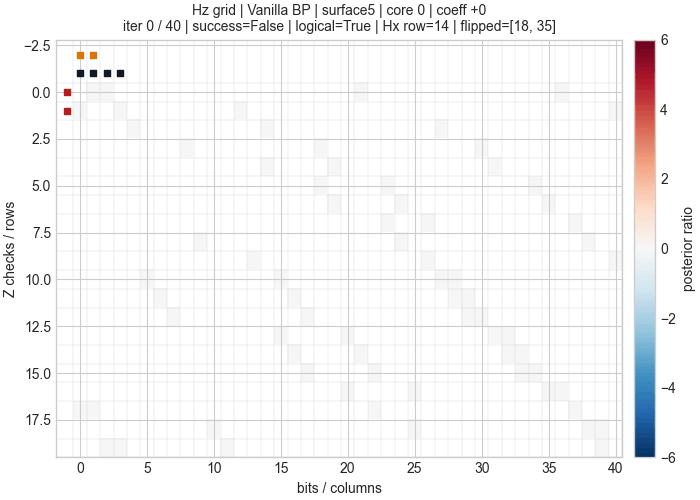

In [12]:
problem = load_code_problem(npz_path)
display(code_summary_table(problem))
preview_experiment = run_decoder_experiment(selected_core_seed, selected_decoder_kind, problem)
preview_artifacts = render_experiment_preview(preview_experiment, requested_mode= "hz_grid")


## Batch Export

This is the larger sweep path. Keep `animation_formats = ("gif",)` unless you explicitly want MP4 and have `ffmpeg` available.


In [10]:
problem = load_code_problem(npz_path)
batch_run_table, batch_animation_table = export_seed_batch(
    problem,
    selected_decoder_kind,
    batch_core_seeds,
)
display(batch_run_table)
display(batch_animation_table)


,decoder,core_seed,coeff_seed,coeff_seed_offset,success,logical_success,exact_recovery,logical_weight,iterations,n_support_bits,n_flipped_bits,n_estimated_bits,estimated_bits_in_support,estimated_bits_outside_support
0,Vanilla BP,1,1,0,False,True,False,0,40,4,2,0,[],[]
1,Vanilla BP,2,2,0,False,True,False,0,40,4,2,2,"[17, 35]",[]
2,Vanilla BP,3,3,0,False,True,False,0,40,4,2,2,"[16, 34]",[]


,visualization_mode,decoder,core_seed,coeff_seed_offset,format,path
0,graph,Vanilla BP,1,0,gif,c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.tmp\marginal_spatial_animations\hz_grid\surface5_bp_core1_coeffplus0_graph.gif
1,graph,Vanilla BP,2,0,gif,c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.tmp\marginal_spatial_animations\hz_grid\surface5_bp_core2_coeffplus0_graph.gif
2,graph,Vanilla BP,3,0,gif,c:\Users\User\Documents\projects-git\relay_mother_folder\relay\.tmp\marginal_spatial_animations\hz_grid\surface5_bp_core3_coeffplus0_graph.gif
